# Machine Learning Assessment Project- Classification
###

Si Tang Lin

Data Science and Business Analytics

Student id: 476912

**Use python3.10 venv to run**


## Check README.txt

**Environment**
- Python 3.10
- Tested on Python 3.10.12

**Setup**
- python3.10 -m venv venv
- source venv/bin/activate  (Linux/Mac)
- venv\Scripts\activate     (Windows)


## 1. Import Libraries

**Check requirements.txt if needed**

In [ ]:
## Import libraries
#pip install -r requirements.txt
import os
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    chi2_contingency,
    pointbiserialr,
    ttest_ind,
    kruskal
)
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    PowerTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import category_encoders as ce

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    SelectFromModel,
    SequentialFeatureSelector
)
from sklearn.decomposition import PCA

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_sample_weight
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support,
    make_scorer
)

import sklearn


## 2. Load & Inspect Data
**Dataset: Predict Students' Dropout and Academic Success (UCI ML Repo)**

##### Key Details
- Source: UCI Machine Learning Repository
- URL: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success



In [ ]:
## Load and inspect data

student_dropout = pd.read_csv("data/students dropout_data.csv")

print(student_dropout.head())
print(student_dropout.info())
print(student_dropout.describe())
print("Missing values:\n", student_dropout.isnull().sum())

# No missing value in our dataset
# All variables were cast to integers for processing.
# To ensure correct treatment of variable types (numeric, ordinal, nominal)
# We restore each column to its appropriate original data type.


   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

## 3. Train, Validation and Test data split

**Split the datat into training, validation and testing data sets**
- Train the models and Tune hyperparameters on the training set
- Access true generalization performance using the validation set
- Evaluate final performance on an unseen test set

**1. Reserve 20% of the data as a test set to evaluate**

**2. Validation set is 15% of the training data**


In [4]:
# 1. Train/ Test split

X_train, X_test, y_train, y_test = train_test_split(
    student_dropout.drop(columns="Target"),
    student_dropout["Target"],
    test_size=0.2,
    stratify=student_dropout["Target"],
    random_state=42
)

print("Successfully split train and test")

Successfully split train and test


In [5]:
## 2. Train and Validation split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,         
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print("Train and Validation split done")


(3008, 36)
(531, 36)
(885, 36)
Train and Validation split done


## 4. Variable Typing

**Assign variable types to ensure each feature is processed correctly during preprocessing**

##### Main Purpose
- Selecting appropriate encoding strategies
- Applying scaling only to numerical variables

In [6]:
## Assigning data type
nominal_cols = ["Marital status", "Application mode", "Course", "Nacionality",
                "Mother's occupation", "Father's occupation"]

ordinal_cols = ["Application order", "Previous qualification",
                "Mother's qualification", "Father's qualification"]

numeric_cols = [
    "Previous qualification (grade)", "Admission grade", "Age at enrollment",
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

binary_cols = [
    "Displaced", "Daytime/evening attendance", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender",
    "Scholarship holder", "International"
]



In [7]:
## Restore to original data type
def assign_variable_types(df):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # nominal + ordinal + binary → category
    for c in nominal_cols + ordinal_cols + binary_cols:
        if c in df.columns:
            df[c] = df[c].replace(r'^\s*$', np.nan, regex=True)
            df[c] = df[c].astype('category')

    # numeric → numeric
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    return df

In [8]:
## Fit and Transform
X_train  = assign_variable_types(X_train)
X_val = assign_variable_types(X_val)

## 4. Near Zero Variance

**NZV features provide little to no predictive power and may negatively affect model performance.**

##### Identify such features based on:
- 1. Frequency ratio: dominance of the most common value

- 2. Unique ratio: proportion of unique values relative to sample size

In [9]:
## 1. Define NZV function 
def near_zero_var(df, freq_cut=95/5, unique_cut=10):

    results = []
    for col in df.columns:
        counts = df[col].value_counts()

        if len(counts) > 1:
            freq_ratio = counts.iloc[0] / counts.iloc[1]
        else:
            freq_ratio = float('inf') 

        unique_ratio = len(counts) / len(df)

        high_freq_ratio = int(freq_ratio > freq_cut)
        low_unique_ratio = int(unique_ratio < unique_cut)

        results.append({
            'variable': col,
            'freq_ratio': freq_ratio,
            'unique_ratio': unique_ratio,
            'high_freq_ratio': high_freq_ratio,
            'low_unique_ratio': low_unique_ratio
        })
    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(by=['freq_ratio', 'unique_ratio'], ascending=[False, True])

    return results_df

In [10]:
## Apply to the dataset
X_train_nzv = near_zero_var(X_train, freq_cut=97/3, unique_cut=10)
X_train_nzv[(X_train_nzv['low_unique_ratio'] == 1) & (X_train_nzv['high_freq_ratio'] == 1)]

,variable,freq_ratio,unique_ratio,high_freq_ratio,low_unique_ratio
7,Nacionality,127.608696,0.005652,1,1
14,Educational special needs,87.470588,0.000665,1,1
20,International,40.205479,0.000665,1,1
21,Curricular units 1st sem (credited),39.621212,0.006981,1,1
27,Curricular units 2nd sem (credited),36.273973,0.006316,1,1


In [11]:
## 2. Chi-square method to check if we can drop the variable

chi2_results = []

# : Near-zero variance variables
nzv_vars = [
    'Nacionality',
    'Educational special needs',
    'Curricular units 1st sem (credited)',
    'International',
    'Curricular units 2nd sem (credited)'
]

# : Multi-class Chi-square on NZV variables
for col in nzv_vars:
    
    if col not in X_train.columns:
        continue
    
    table = pd.crosstab(X_train[col], y_train)

    if table.shape[0] < 2:
        chi2_results.append([col, None, None])
        continue
    
    chi2, p, dof, expected = chi2_contingency(table)
    chi2_results.append([col, p, dof])

chi2_df = pd.DataFrame(chi2_results, columns=['variable', 'p_value', 'dof'])
print("\n= Chi-square results on NZV variables (multi-class Target) =")
print(chi2_df.sort_values('p_value'))


# Null Hypothesis: There is no statistically significant relationship between the two variables.
# There is a significant relationship between Curricular units 1st sem (credited), Curricular units 2nd sem (credited) and target variable, we proceed with further analysis on this variable.
# The relationship between Nacionality, International, Educational special needs and the target is not statistically significant.
### We drop "Nacionality", "International", "Educational special need"


= Chi-square results on NZV variables (multi-class Target) =
                              variable   p_value  dof
3                        International  0.152873    2
2  Curricular units 1st sem (credited)  0.281540   40
0                          Nacionality  0.330917   32
4  Curricular units 2nd sem (credited)  0.638199   36
1            Educational special needs  0.788862    2


In [12]:
## Initial Decisions on Near-Zero Variance

DROP_COLS_NZV = [
    'Nacionality',
    'International',
    'Educational special needs'
]
def drop_nzv_features(df):
    df = df.copy()
    df = df.drop(columns=[c for c in DROP_COLS_NZV if c in df.columns])
    return df


In [13]:
## Fit and Transform
X_train  = drop_nzv_features(X_train)
X_val = drop_nzv_features(X_val)

## 5. EDA& Feature Inspection

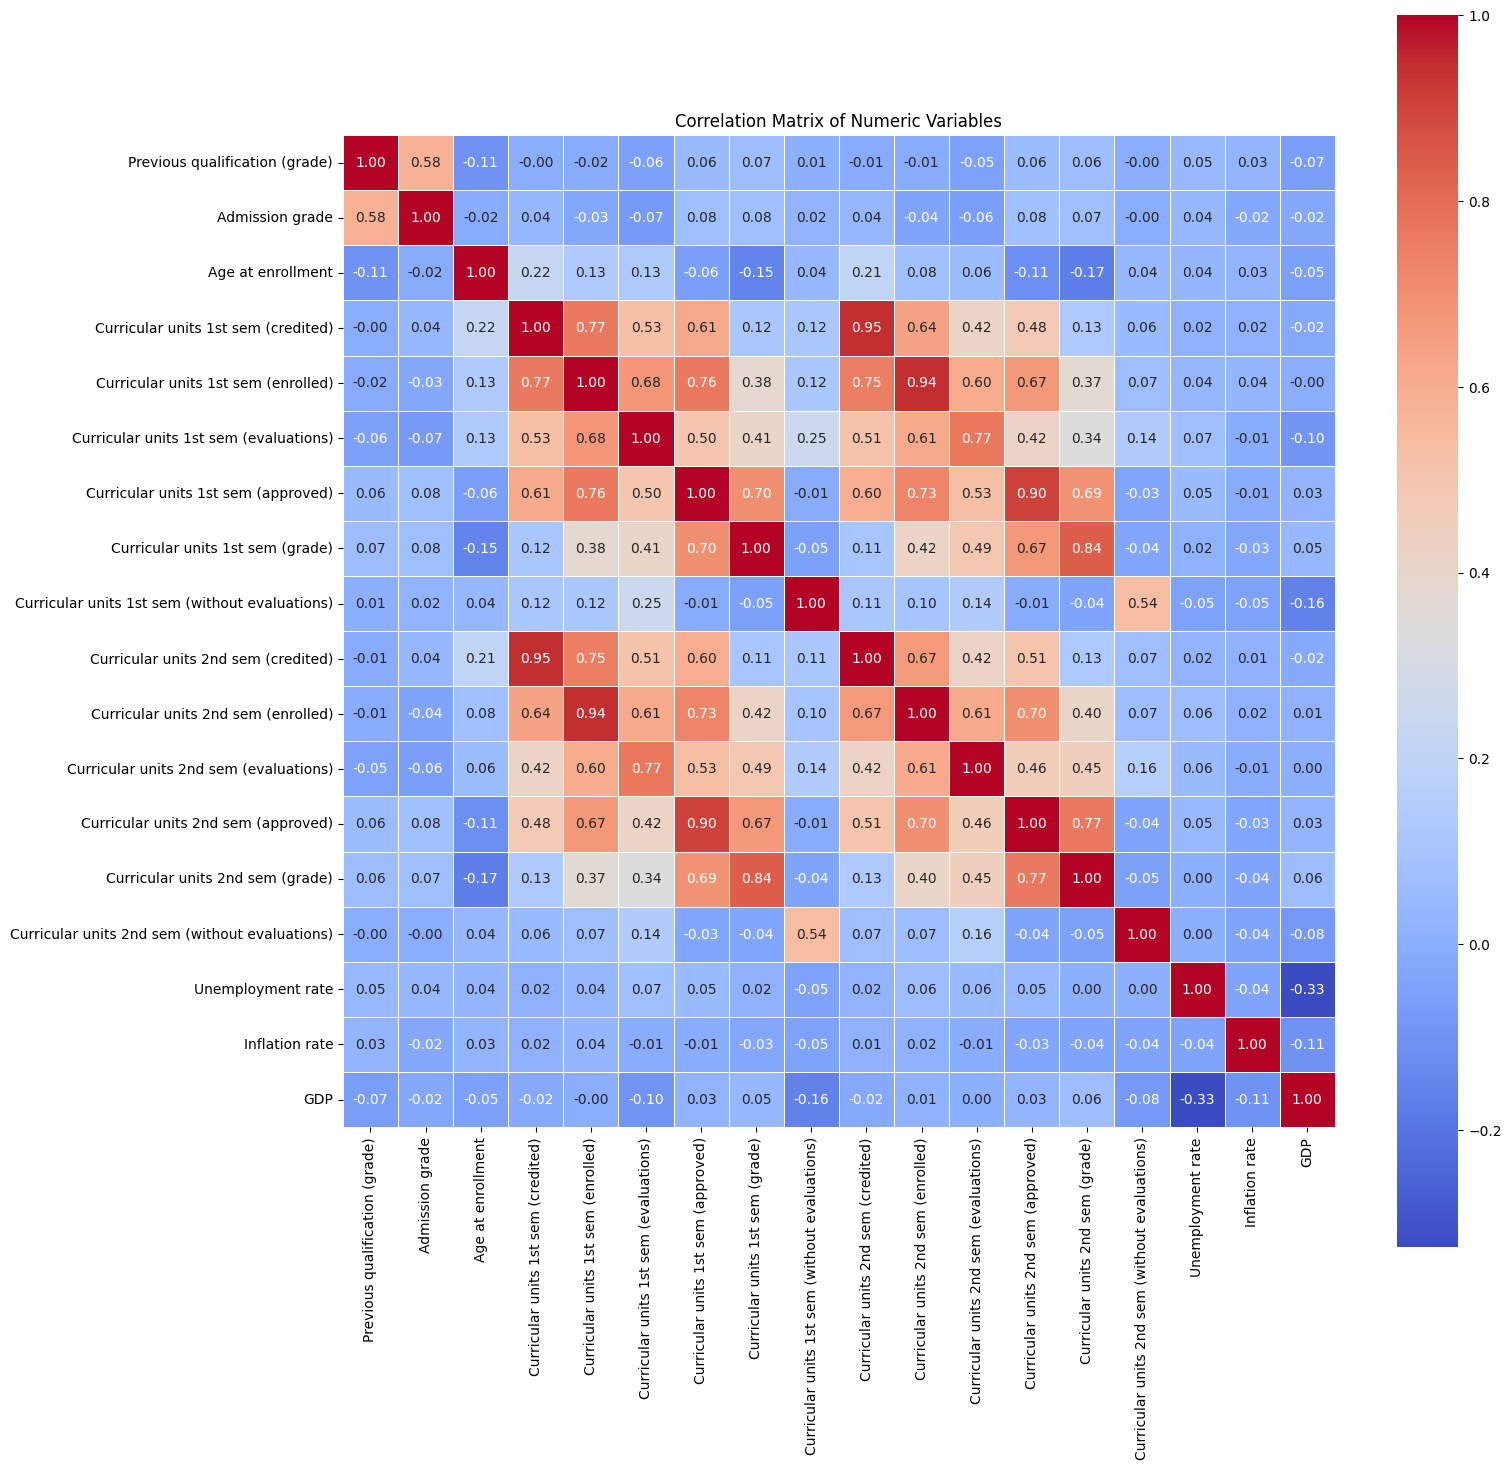

In [14]:
# Correlation Matrix

numeric_cols = X_train.select_dtypes(include='number')

corr_matrix = numeric_cols.corr()
plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

**Present an overall weak correlation through all variables**

-  Curricular units 1st sem/2nd sem might have collinearity, between variable"evaluations", "approved", "grade", "credited", "enrolled". We need to delete to prevent multicollineraity, so se PCA to reduce the dimension

##### The plot imply the lower the grade the easier to dropout

In [ ]:
## PCA analysis

pca_vars_1st = [
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)'
]

pca_vars_2nd = [
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)'
]


def inspect_pca(df, var_list, name):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[var_list])

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(X_scaled)

    print(f"\n===== {name} =====")
    print("Explained Variance Ratio:", pca.explained_variance_ratio_[0])
    print("Loadings:")
    print(pd.Series(pca.components_[0], index=var_list))

def fit_pca_block(df, var_list, n_components=1):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[var_list])

    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(X_scaled)

    return {
        "vars": var_list,
        "scaler": scaler,
        "pca": pca
    }
pca_1st_block = fit_pca_block(X_train, pca_vars_1st)
pca_2nd_block = fit_pca_block(X_train, pca_vars_2nd)

In [17]:
## Apply PCA feature
def apply_pca_block(df, pca_block, new_name):
    df = df.copy()
    X_scaled = pca_block["scaler"].transform(df[pca_block["vars"]])
    df[new_name] = pca_block["pca"].transform(X_scaled)
    return df

## Derop column
PCA_DROP_COLS = pca_vars_1st + pca_vars_2nd

def drop_pca_original_vars(df):
    df = df.copy()
    return df.drop(columns=[c for c in PCA_DROP_COLS if c in df.columns])


In [ ]:
## Fit and Transform

X_train  = apply_pca_block(X_train,  pca_1st_block, "PCA_1st_sem")
X_val = apply_pca_block(X_val, pca_1st_block, "PCA_1st_sem")
X_train  = apply_pca_block(X_train,  pca_2nd_block, "PCA_2nd_sem")
X_val = apply_pca_block(X_val, pca_2nd_block, "PCA_2nd_sem")

# drop original vars
X_train  = drop_pca_original_vars(X_train)
X_val = drop_pca_original_vars(X_val)


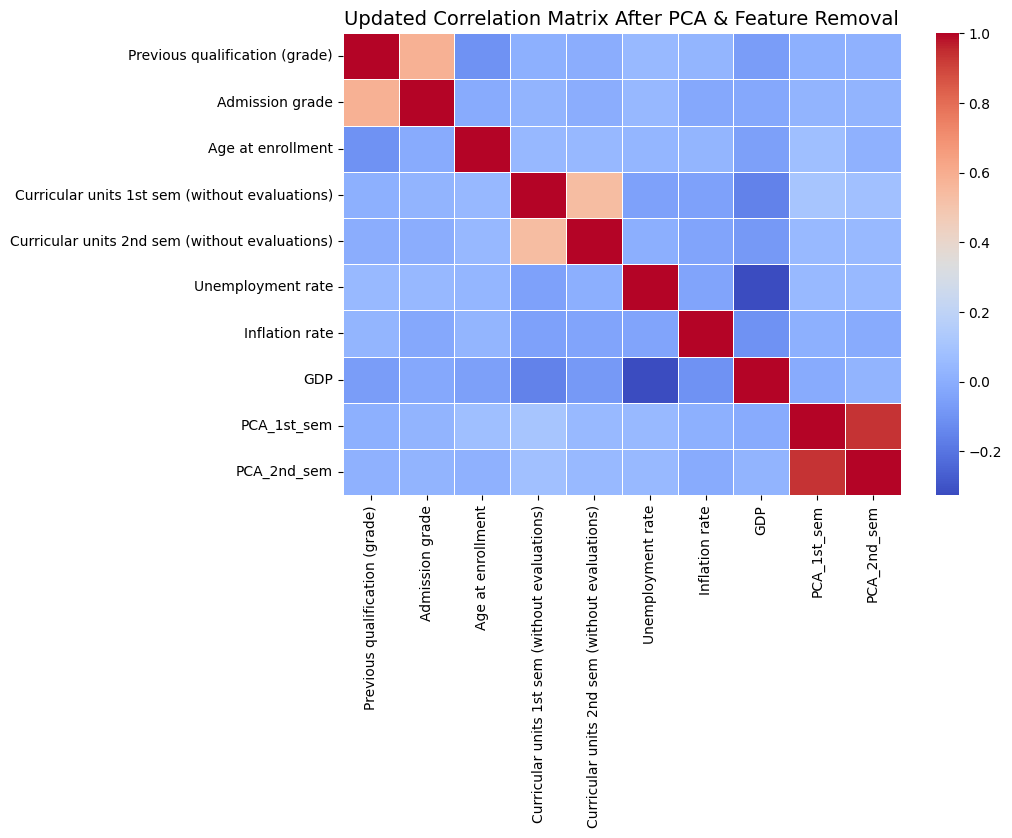

In [21]:
# Correlation heatmap after PCA
numeric_df = X_train.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(9, 6))
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f',
    square=False
)
plt.title("Updated Correlation Matrix After PCA & Feature Removal", fontsize=14)
plt.show()

## 6. Feature Engineering

In [ ]:
# Check column before processing
print(X_train.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'PCA_1st_sem', 'PCA_2nd_sem']


### 6.1 Numerical variable

- 1.Kruskal–Wallis test tests whether the distributions of a numerical variable differ significantly across multiple target classes.

- 2.Add features base on distribution plot 

- 3.Intentionally do not apply feature scaling at this stage.


In [ ]:
## 1. Kruskal–Wallis test

from scipy.stats import kruskal

numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

for col in numeric_cols:
    groups = [
        X_train[col][y_train == level]
        for level in y_train.unique()
    ]
    stat, p = kruskal(*groups)
    print(f'{col}: p-value = {p}')


## We can delete "inflation rate",as it might cause noise in the model

Previous qualification (grade): p-value = 1.3911168301425566e-11
Admission grade: p-value = 2.744193937001361e-13
Age at enrollment: p-value = 2.4406968687915766e-57
Curricular units 1st sem (without evaluations): p-value = 1.4599530270406185e-05
Curricular units 2nd sem (without evaluations): p-value = 3.4277511407148457e-06
Unemployment rate: p-value = 0.05018076827793334
GDP: p-value = 0.005964201926327835
PCA_1st_sem: p-value = 1.0102775873329517e-95
PCA_2nd_sem: p-value = 2.03889530559882e-147
grade_ratio: p-value = 0.8671507964780528
is_mature_student: p-value = 1.5520864115516017e-55
performance_drop: p-value = 0.0022389606857852354


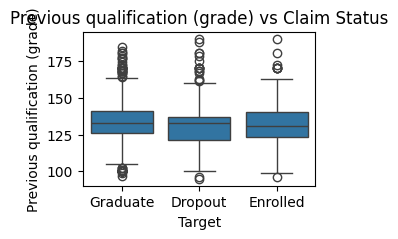

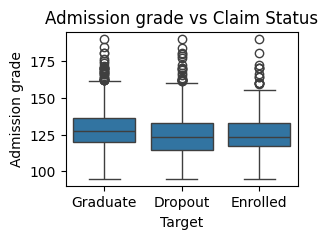

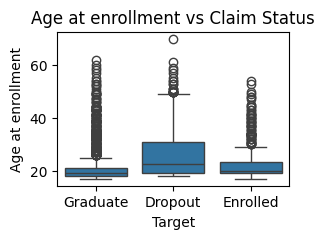

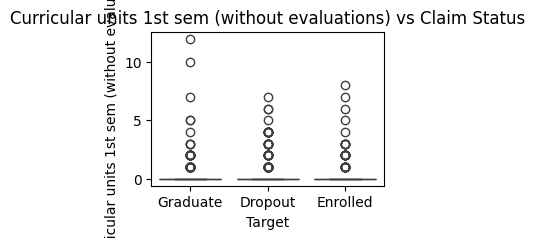

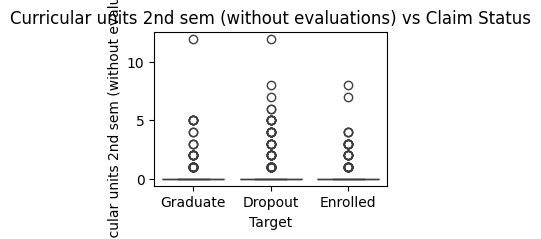

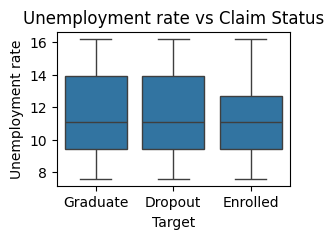

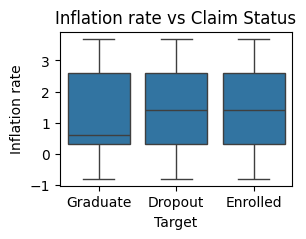

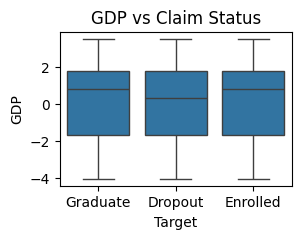

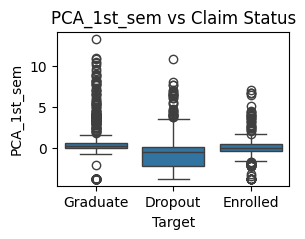

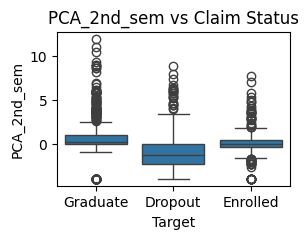

In [ ]:
# plot sidtribution Numeric variables x target variable plot

numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(3, 2))
    sns.boxplot(x=y_train, y=X_train[col])
    plt.title(f'{col} vs Claim Status')
    
    plt.show()

In [29]:
## 2. Drop feature and add variable
DROP_COLS_EXTRA = [
    'Inflation rate'
]

def add_engineered_features(df):
    df = df.copy()
    epsilon = 1e-5

    # grade ratio
    if (
        "Admission grade" in df.columns and
        "Previous qualification (grade)" in df.columns
    ):
        df["grade_ratio"] = (
            df["Admission grade"] /
            (df["Previous qualification (grade)"] + epsilon)
        )

    # mature student
    if "Age at enrollment" in df.columns:
        df["is_mature_student"] = (df["Age at enrollment"] >= 25).astype(int)

    # drop decided numeric features
    df = df.drop(columns=[c for c in DROP_COLS_EXTRA if c in df.columns])

    return df


In [30]:
## Fit and transform

X_train  = add_engineered_features(X_train)
X_val = add_engineered_features(X_val)

In [ ]:
### 3. DONT scaling
## For modeling purpose, we decide not to scale data

#numeric_features = [
    #'Previous qualification (grade)',
    #'Admission grade',
    #'Age at enrollment',
    #'Curricular units 1st sem (without evaluations)',
    #'Curricular units 2nd sem (without evaluations)',
    #'Unemployment rate',
    #'GDP',
    #'PCA_1st_sem',
    #'PCA_2nd_sem',
    #'grade_ratio',
    #'performance_drop']

#scaler = ColumnTransformer(
    #transformers=[
    #   ('scale', StandardScaler(), numeric_features)
    # ],
    #remainder='passthrough' )

### 6.2 Nominal variable

- 1. Cramér’s V, measure of association between two categorical variables.

- 2. Add features base on distribution plot 


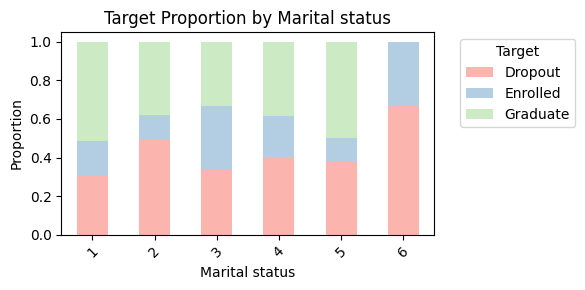

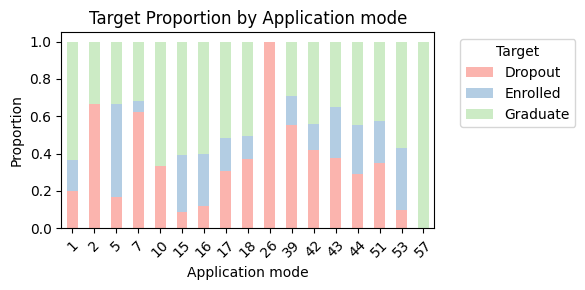

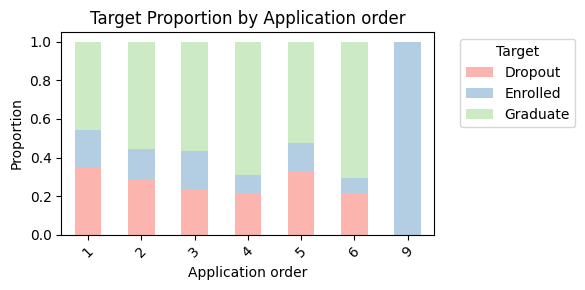

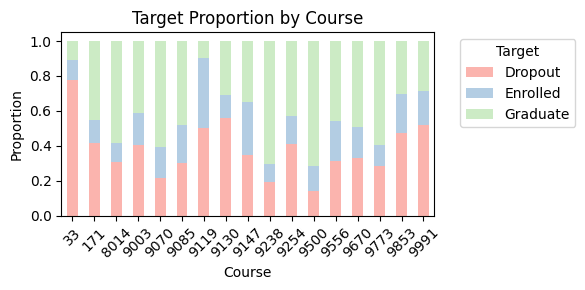

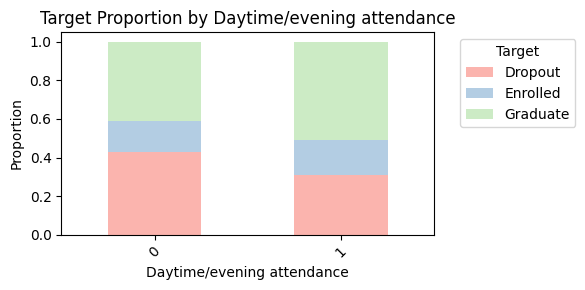

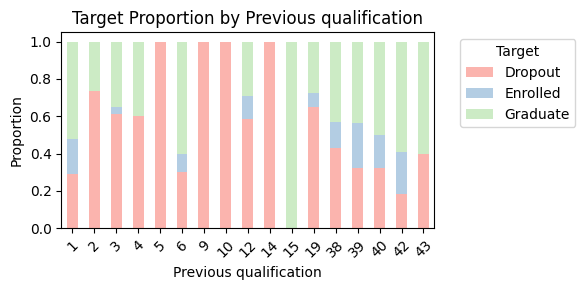

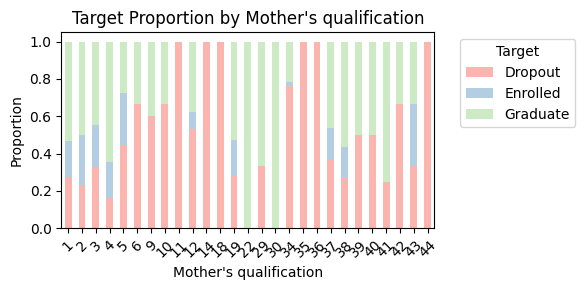

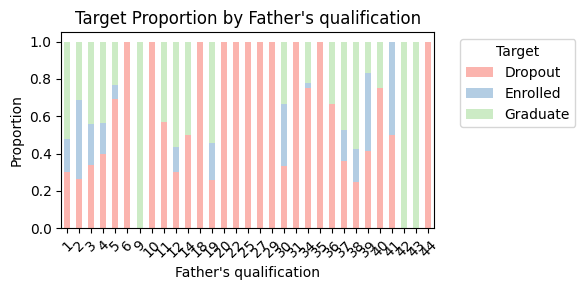

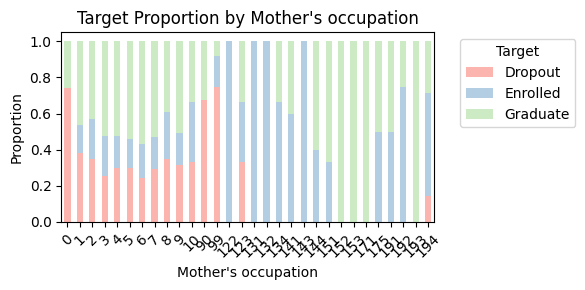

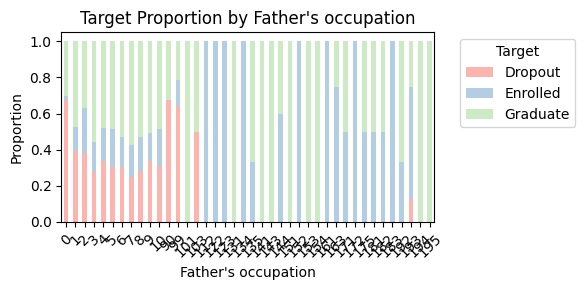

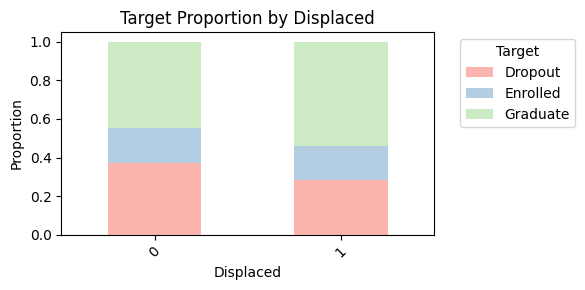

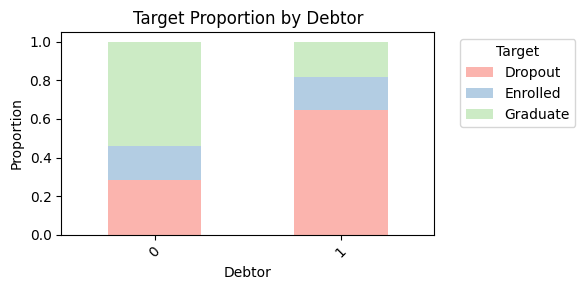

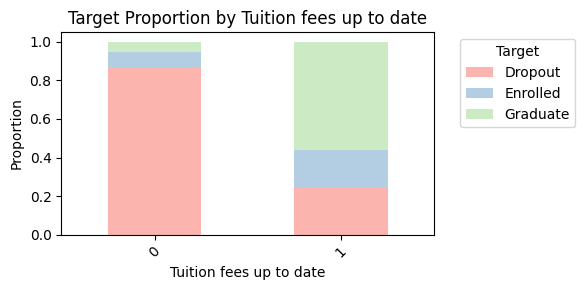

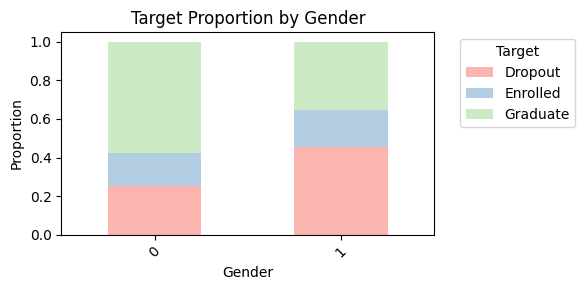

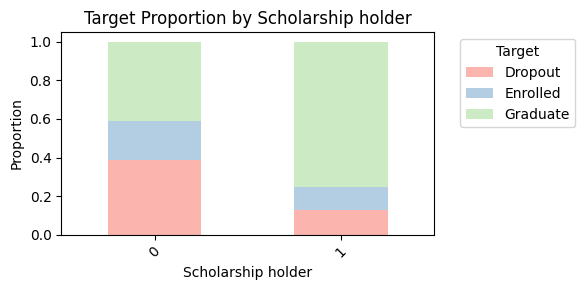

In [24]:
# Nominal variable x target variable distribition plot

nominal_cols = X_train.select_dtypes(include=['category','object']).columns.tolist()
palette = sns.color_palette("Pastel1", n_colors=y_train.nunique())

for col in nominal_cols:
    table = pd.crosstab(X_train[col], y_train)
    prop_df = table.div(table.sum(axis=1), axis=0) 
    ax = prop_df.plot(kind='bar', stacked=True, figsize=(6,3), color=palette)
    
    plt.title(f'Target Proportion by {col}', fontsize=12)
    plt.ylabel('Proportion')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
## 1. Cramer's V
nominal_cols = [
    'Marital status', 
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder'
]
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

# train only analysis
for col in nominal_cols:
    table = pd.crosstab(X_train[col], y_train)
    print(col, "Cramer's V =", cramers_v(table))

Marital status Cramer's V = 0.08444842329664472
Application mode Cramer's V = 0.2377723901792825
Application order Cramer's V = 0.11161683488272187
Course Cramer's V = 0.25689681386181534
Daytime/evening attendance Cramer's V = 0.08248617070291951
Previous qualification Cramer's V = 0.1605449032951729
Mother's qualification Cramer's V = 0.16189044230660293
Father's qualification Cramer's V = 0.1733154965721567
Mother's occupation Cramer's V = 0.19134108958964624
Father's occupation Cramer's V = 0.19019667226054066
Displaced Cramer's V = 0.10281368146887138
Debtor Cramer's V = 0.2569020124602488
Tuition fees up to date Cramer's V = 0.4381396051972133
Gender Cramer's V = 0.2307045733516211
Scholarship holder Cramer's V = 0.30251473941313345


**Cramer's V Analysis**
- 'Application order', 'Marital status' and 'Daytime/evening attendance' show weak association with the target variable and are likely to contribute noise rather than predictive signal.

- We drop these features.



In [ ]:
## 2. Drop features and new variabe

DROP_COLS_CRAMER = [
    'Application order',
    'Marital status',
    'Daytime/evening attendance'
]
def add_categorical_features(df):
    df = df.copy()

    # performance drop
    if (
        "Admission grade" in df.columns and
        "Previous qualification (grade)" in df.columns
    ):
        df["performance_drop"] = (
            df["Admission grade"] < df["Previous qualification (grade)"]
        ).astype(int)

    # age group
    if "Age at enrollment" in df.columns:
        def age_group(age):
            if age < 22:
                return "traditional"
            elif age < 25:
                return "transition"
            else:
                return "mature"

        df["age_group"] = df["Age at enrollment"].apply(age_group).astype("category")

    # drop low-association categorical vars
    df = df.drop(columns=[c for c in DROP_COLS_CRAMER if c in df.columns])

    return df


In [ ]:
## Fit and Transform

X_train  = add_categorical_features(X_train)
X_val = add_categorical_features(X_val)

### 6.3 Enoded

- 1. Label Encoding for target variable, applied to convert multiple class labels into numerical format required by scikit-learn models.

- 2. Different encoding methods are applied based on the characteristics of categorical variables:
- 一一一Target encoding for high-cardinality variables
- 一一一One-hot encoding for low-cardinality nominal variables
- 一一一Numerical variables are passed through unchanged


In [32]:
## 1. Label Encoded for y variable

le = LabelEncoder()
y_train_modeling = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

In [34]:
## 2. Define encoded

high_card_cat = ['Course']

one_hot_cat = [
    'Application mode',
    'Previous qualification',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'age_group'
]

num_cols = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Unemployment rate',
    'GDP',
    'PCA_1st_sem',
    'PCA_2nd_sem',
    'grade_ratio',
    'is_mature_student',
    'performance_drop'
]

target_encoder = ce.TargetEncoder(
    cols=high_card_cat,
    handle_unknown='value',
    handle_missing='value'
)

onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse=False
)

encoder = ColumnTransformer(
    transformers=[
        ('target_enc', target_encoder, high_card_cat),
        ('onehot', onehot_encoder, one_hot_cat),
        ('num', 'passthrough', num_cols),
    ],
    remainder='drop'
)


In [35]:
## Fit and transform
X_train_modeling = encoder.fit_transform(X_train, y_train_modeling)
X_val_enc = encoder.transform(X_val)

/Users/ninalin/venv/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## 7. Distribution of dependent variable

/var/folders/98/vbl85mtj76q2kgtvtsj9xmn00000gn/T/ipykernel_15909/131184434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=student_dropout, x='Target', palette='Pastel1')


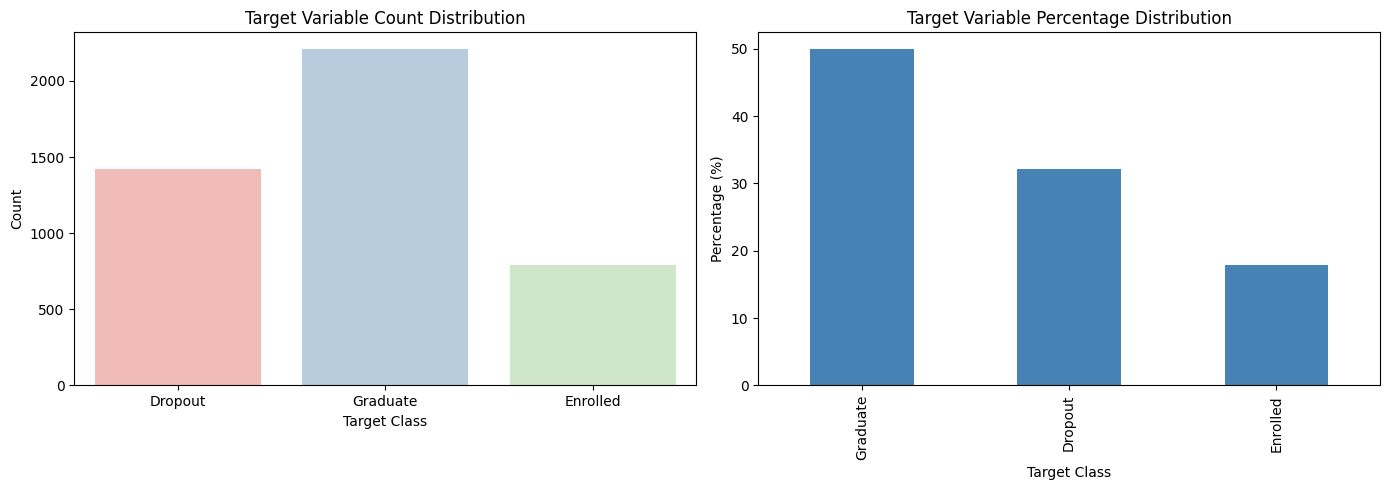

In [32]:
# Plot of dependent variable

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=student_dropout, x='Target', palette='Pastel1')
plt.title("Target Variable Count Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
(student_dropout['Target']
 .value_counts(normalize=True)
 .mul(100)
 .plot(kind='bar', color='steelblue'))

plt.title("Target Variable Percentage Distribution")
plt.xlabel("Target Class")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

**Target Variable Analysis**

- The distribution is clearly imbalanced, with: Graduate being the majority class and  Enrolled being the minority class

- Therefore, class imbalance handling techniques (e.g., SMOTE) are considered in later modeling stages.

## 8. Final Inspection

**Verifies that all preprocessing and feature engineering steps have been applied correctly before model training.**

**We check:**

- Feature names after encoding

- Data dimensions consistency

- Alignment between training and validation sets

In [ ]:
# Final Inspection

X_train_df = pd.DataFrame(
    X_train_modeling,
    columns=encoder.get_feature_names_out()
)

print(X_train_df.head())
print(X_train_df.columns)
print("Train:", X_train_modeling.shape)
print("Val:", X_val_enc.shape)


   target_enc__Course  onehot__Application mode_1  onehot__Application mode_2  \
0            1.310345                         0.0                         0.0   
1            1.163934                         0.0                         0.0   
2            1.391607                         1.0                         0.0   
3            1.572534                         1.0                         0.0   
4            1.572534                         1.0                         0.0   

   onehot__Application mode_5  onehot__Application mode_7  \
0                         0.0                         0.0   
1                         0.0                         0.0   
2                         0.0                         0.0   
3                         0.0                         0.0   
4                         0.0                         0.0   

   onehot__Application mode_10  onehot__Application mode_15  \
0                          0.0                          0.0   
1                   

## 9. Model Training with Class Imbalance Handling

**Model Training and Hyperparameter Tuning under Class Imbalance**

- 1. Gradient Boosting + Undersampling（Pipeline）

- 2. XGBoost（Baseline + Early Stopping）

- 3. XGBoost + Sample Weight（Weighted Loss）

- 4. Random Forest + Class Weight

- 5. Model Evaluation


In [ ]:
## 1. Gradient Boosting + Undersampling（Pipeline）

models = {
    #"Logistic Regression": LogisticRegression(max_iter=1000),
    #"Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    #"SVM (RBF Kernel)": SVC(probability=True, random_state=42),
    #"KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}


models_under = {
    "GB + Undersampling": Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
}
def evaluate_models(models_dict, X_train, y_train, X_val_enc, y_val_enc, results):
    for name, model in models_dict.items():
        print(f"\n===== Training {name} =====")
        
        model.fit(X_train, y_train)
        preds = model.predict(X_val_enc)

        acc = accuracy_score(y_val_enc, preds)
        results[name] = acc

        print(f"Accuracy: {acc:.4f}")
        print("Confusion Matrix:")
        print(confusion_matrix(y_val_enc, preds))
        print("Classification Report:")
        print(classification_report(y_val_enc, preds))

gb_under = models_under["GB + Undersampling"]

gb_under.fit(X_train_modeling, y_train_modeling)

results = {}
evaluate_models(models, X_train_modeling, y_train_modeling, X_val_enc, y_val_enc, results)



===== Training Gradient Boosting =====
Accuracy: 0.7514
Confusion Matrix:
[[127  11  33]
 [ 17  25  53]
 [ 12   6 247]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.78       171
           1       0.60      0.26      0.36        95
           2       0.74      0.93      0.83       265

    accuracy                           0.75       531
   macro avg       0.72      0.65      0.66       531
weighted avg       0.74      0.75      0.73       531



**1. Gradient Boosting + Undersampling Analysis**

- Gradient Boosting favors the majority class and struggles to correctly identify minority samples, leading to low recall for the minority class.

In [ ]:
# 2. XGBoost（Baseline + Early Stopping）

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(
    X_train_modeling,
    y_train_modeling,
    eval_set=[(X_val_enc, y_val_enc)],
    early_stopping_rounds=30,
    verbose=True
)

val_pred_xgb = xgb.predict(X_val_enc)

print("=== XGBoost Validation Performance ===")
print("Accuracy:", accuracy_score(y_val_enc, val_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_enc, val_pred_xgb))
print("\nClassification Report:\n", classification_report(y_val_enc, val_pred_xgb))


[0]	validation_0-mlogloss:1.06842
[1]	validation_0-mlogloss:1.04086
[2]	validation_0-mlogloss:1.01581
[3]	validation_0-mlogloss:0.99364


/Users/ninalin/venv/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[4]	validation_0-mlogloss:0.97205
[5]	validation_0-mlogloss:0.95369
[6]	validation_0-mlogloss:0.93454
[7]	validation_0-mlogloss:0.91700
[8]	validation_0-mlogloss:0.90079
[9]	validation_0-mlogloss:0.88648
[10]	validation_0-mlogloss:0.87307
[11]	validation_0-mlogloss:0.86005
[12]	validation_0-mlogloss:0.84885
[13]	validation_0-mlogloss:0.83732
[14]	validation_0-mlogloss:0.82643
[15]	validation_0-mlogloss:0.81877
[16]	validation_0-mlogloss:0.80880
[17]	validation_0-mlogloss:0.79918
[18]	validation_0-mlogloss:0.79007
[19]	validation_0-mlogloss:0.78224
[20]	validation_0-mlogloss:0.77466
[21]	validation_0-mlogloss:0.76711
[22]	validation_0-mlogloss:0.76255
[23]	validation_0-mlogloss:0.75702
[24]	validation_0-mlogloss:0.75057
[25]	validation_0-mlogloss:0.74442
[26]	validation_0-mlogloss:0.73862
[27]	validation_0-mlogloss:0.73402
[28]	validation_0-mlogloss:0.72943
[29]	validation_0-mlogloss:0.72472
[30]	validation_0-mlogloss:0.71995
[31]	validation_0-mlogloss:0.71481
[32]	validation_0-mlogloss

**2. XGBoost（Baseline + Early Stopping Analysis**

- the baseline XGBoost achieves the highest overall accuracy, it performs poorly on the minority class, indicating a bias toward the majority class. Accuracy alone is therefore insufficient to assess model quality under class imbalance.

In [ ]:
## 3. XGBoost + Sample Weight（Weighted Loss）

sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y_train_modeling
)

xgb_weighted = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_weighted.fit(
    X_train_modeling,
    y_train_modeling,
    sample_weight=sample_weight
)

val_pred_xgb_w = xgb_weighted.predict(X_val_enc)

print("=== XGBoost (sample_weight balanced) ===")
print(classification_report(y_val_enc, val_pred_xgb_w))


=== XGBoost (sample_weight balanced) ===
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       171
           1       0.44      0.57      0.50        95
           2       0.82      0.79      0.81       265

    accuracy                           0.73       531
   macro avg       0.69      0.70      0.69       531
weighted avg       0.75      0.73      0.74       531



**3. XGBoost (sample_weight balanced) Analysis**

- Applying sample weights improves recall and F1-score for the minority class without significantly degrading overall accuracy. This indicates that loss reweighting helps the model pay more attention to underrepresented classes.

In [ ]:
## 4. Random Forest + Class Weight

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  
)

rf_balanced.fit(X_train_modeling, y_train_modeling)

val_pred_rf_bal = rf_balanced.predict(X_val_enc)

print("=== Random Forest (class_weight='balanced') Validation Performance ===")
print("Accuracy:", accuracy_score(y_val_enc, val_pred_rf_bal))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_enc, val_pred_rf_bal))
print("\nClassification Report:\n", classification_report(y_val_enc, val_pred_rf_bal))


=== Random Forest (class_weight='balanced') Validation Performance ===
Accuracy: 0.7325800376647834

Confusion Matrix:
 [[128   7  36]
 [ 21  12  62]
 [ 11   5 249]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77       171
           1       0.50      0.13      0.20        95
           2       0.72      0.94      0.81       265

    accuracy                           0.73       531
   macro avg       0.67      0.60      0.60       531
weighted avg       0.71      0.73      0.69       531



**4. Random Forest (class_weight='balanced') Analysis**

- Tree bagging alone is insufficient to handle severe class imbalance in this dataset, especially when minority samples are sparse and overlapping with majority classes.

**5.Final Inspection**
- XGBoost with sample_weight (balanced) is selected as the final model because it provides the best trade-off between overall performance and fairness across classes, particularly by significantly improving minority-class recall while maintaining competitive accuracy.

## 10. Holdout Set Evaluation


**Evaluate the selected models on a unseen holdout (test) set.**

**Purpose of this evaluation is to:**

- Estimate the true generalization performance of the models

- Verify that performance gains observed on the validation set are not due to overfitting

- Support a fair and unbiased final model selection


In [ ]:
## Validation define
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    log_loss
)

def validate_model(name, model, X_val_enc, y_val_enc, has_proba=True):
    print(f"\n========== {name} ==========")

    y_pred = model.predict(X_val_enc)

    print("Confusion Matrix:")
    print(confusion_matrix(y_val_enc, y_pred))

    print("Classification Report:")
    print(classification_report(y_val_enc, y_pred))

    f1_macro = f1_score(y_val_enc, y_pred, average='macro')
    f1_weighted = f1_score(y_val_enc, y_pred, average='weighted')

    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")

    if has_proba:
        y_proba = model.predict_proba(X_val_enc)
        ll = log_loss(y_val_enc, y_proba)
        print(f"Log Loss: {ll:.4f}")
    else:
        ll = None

    return {
        "model": name,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "log_loss": ll
    }


In [48]:
## Validation result
results = []

results.append(validate_model(
    "XGB (sample_weight balanced)",
    xgb_weighted,
    X_val_enc, y_val_enc,
    has_proba=True
))

results.append(validate_model(
    "XGB (early stopping)",
    xgb,
    X_val_enc, y_val_enc,
    has_proba=True
))

results.append(validate_model(
    "Random Forest (class_weight)",
    rf_balanced,
    X_val_enc, y_val_enc,
    has_proba=True
))

results.append(validate_model(
    "GB + Undersampling",
    gb_under,
    X_val_enc, y_val_enc,
    has_proba=True
))




========== XGB (sample_weight balanced) ==========
Confusion Matrix:
[[125  26  20]
 [ 16  54  25]
 [ 12  43 210]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       171
           1       0.44      0.57      0.50        95
           2       0.82      0.79      0.81       265

    accuracy                           0.73       531
   macro avg       0.69      0.70      0.69       531
weighted avg       0.75      0.73      0.74       531

F1 Macro: 0.6916
F1 Weighted: 0.7402
Log Loss: 0.6521

========== XGB (early stopping) ==========
Confusion Matrix:
[[124  10  37]
 [ 23  29  43]
 [ 11   8 246]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.75       171
           1       0.62      0.31      0.41        95
           2       0.75      0.93      0.83       265

    accuracy                           0.75       531
   macro avg       0.72

In [ ]:
## Present validation result

df_results = pd.DataFrame(results)
print(df_results.sort_values(by="f1_macro", ascending=False))

                          model  f1_macro  f1_weighted  log_loss
0  XGB (sample_weight balanced)  0.680251     0.735795  0.650017
1          XGB (early stopping)  0.664912     0.731284  0.621303
3            GB + Undersampling  0.651515     0.694017  0.732652
2  Random Forest (class_weight)  0.596273     0.691244  0.686372


**Final Model Selection**

- XGBoost with sample weighting is selected as the final model because it achieves the best balance between overall performance, minority-class recall, and generalization stability on the holdout set.

- Why not others?
- Accuracy-focused models → unfair to minority class
- Undersampling → excessive information loss
- Random Forest → insufficient sensitivity

## 11. Test Data Preprocessing

- Prepare a unified training dataset by combining the training and validation sets.

- Apply the same preprocessing steps learned from the training data to the test set.(All transformations (NZV removal, PCA, feature engineering,
encoding) are reused from the training stage.)


In [ ]:
## Combine traain and val dataset
feature_names = encoder.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_modeling,
    columns=feature_names
)

X_val_df = pd.DataFrame(
    X_val_enc,
    columns=feature_names
)

X_trainval_df = pd.concat([X_train_df, X_val_df], axis=0)


In [50]:
## Preprocess Test data

# Assign variable type
X_test = assign_variable_types(X_test)

# nzv
X_test = drop_nzv_features(X_test)

# PCA
X_test = apply_pca_block(X_test, pca_1st_block, "PCA_1st_sem")
X_test = apply_pca_block(X_test, pca_2nd_block, "PCA_2nd_sem")
X_test = drop_pca_original_vars(X_test)

# Nominal
X_test = add_engineered_features(X_test)

# Categorical
X_test = add_categorical_features(X_test)

# Encoded
y_test_enc = le.transform(y_test)
X_test_enc = encoder.transform(X_test)

In [ ]:
## Inspection
assert X_train_modeling.shape[1] == X_test_enc.shape[1]
assert X_test_enc.shape[0] == len(y_test_enc)


## 12. Final Model Evaluation on the Test Set

In [ ]:
##  Model Evaluation on the Test Set

y_test_pred = xgb_weighted.predict(X_test_enc)
print("=== Test Performance ===")
print(confusion_matrix(y_test_enc, y_test_pred))
print(classification_report(y_test_enc, y_test_pred))

f1_macro = f1_score(y_test_enc, y_test_pred, average='macro')
print("Test F1 Macro:", f1_macro)
y_test_proba = xgb_weighted.predict_proba(X_test_enc)
print("Test Log Loss:", log_loss(y_test_enc, y_test_proba))


=== Test Performance ===
[[193  42  49]
 [ 32  72  55]
 [ 32  63 347]]
              precision    recall  f1-score   support

           0       0.75      0.68      0.71       284
           1       0.41      0.45      0.43       159
           2       0.77      0.79      0.78       442

    accuracy                           0.69       885
   macro avg       0.64      0.64      0.64       885
weighted avg       0.70      0.69      0.69       885

Test F1 Macro: 0.6397402047218964
Test Log Loss: 0.7218082881723212


**Final Test Set Evaluation Summary**

The final evaluation on the holdout test set confirms the generalization ability of the selected model. The XGBoost model with sample weighting achieves an overall accuracy of 0.69, a macro F1-score of 0.64, and a weighted F1-score of 0.69.
Importantly, the model demonstrates improved performance on the minority class (Class 1), achieving a recall of 0.45, which is substantially higher than that of baseline and non-weighted models. This indicates that loss-level class imbalance handling effectively mitigates majority-class bias without excessively sacrificing overall performance.
Although the overall accuracy is slightly lower than some baseline models, the balanced performance across classes—reflected by the macro F1-score—suggests that the model provides a fairer and more robust solution for this imbalanced multi-class classification problem.
Therefore, XGBoost with sample weighting is selected as the final model, as it offers the best trade-off between generalization performance, minority-class detection, and model stability on unseen data.